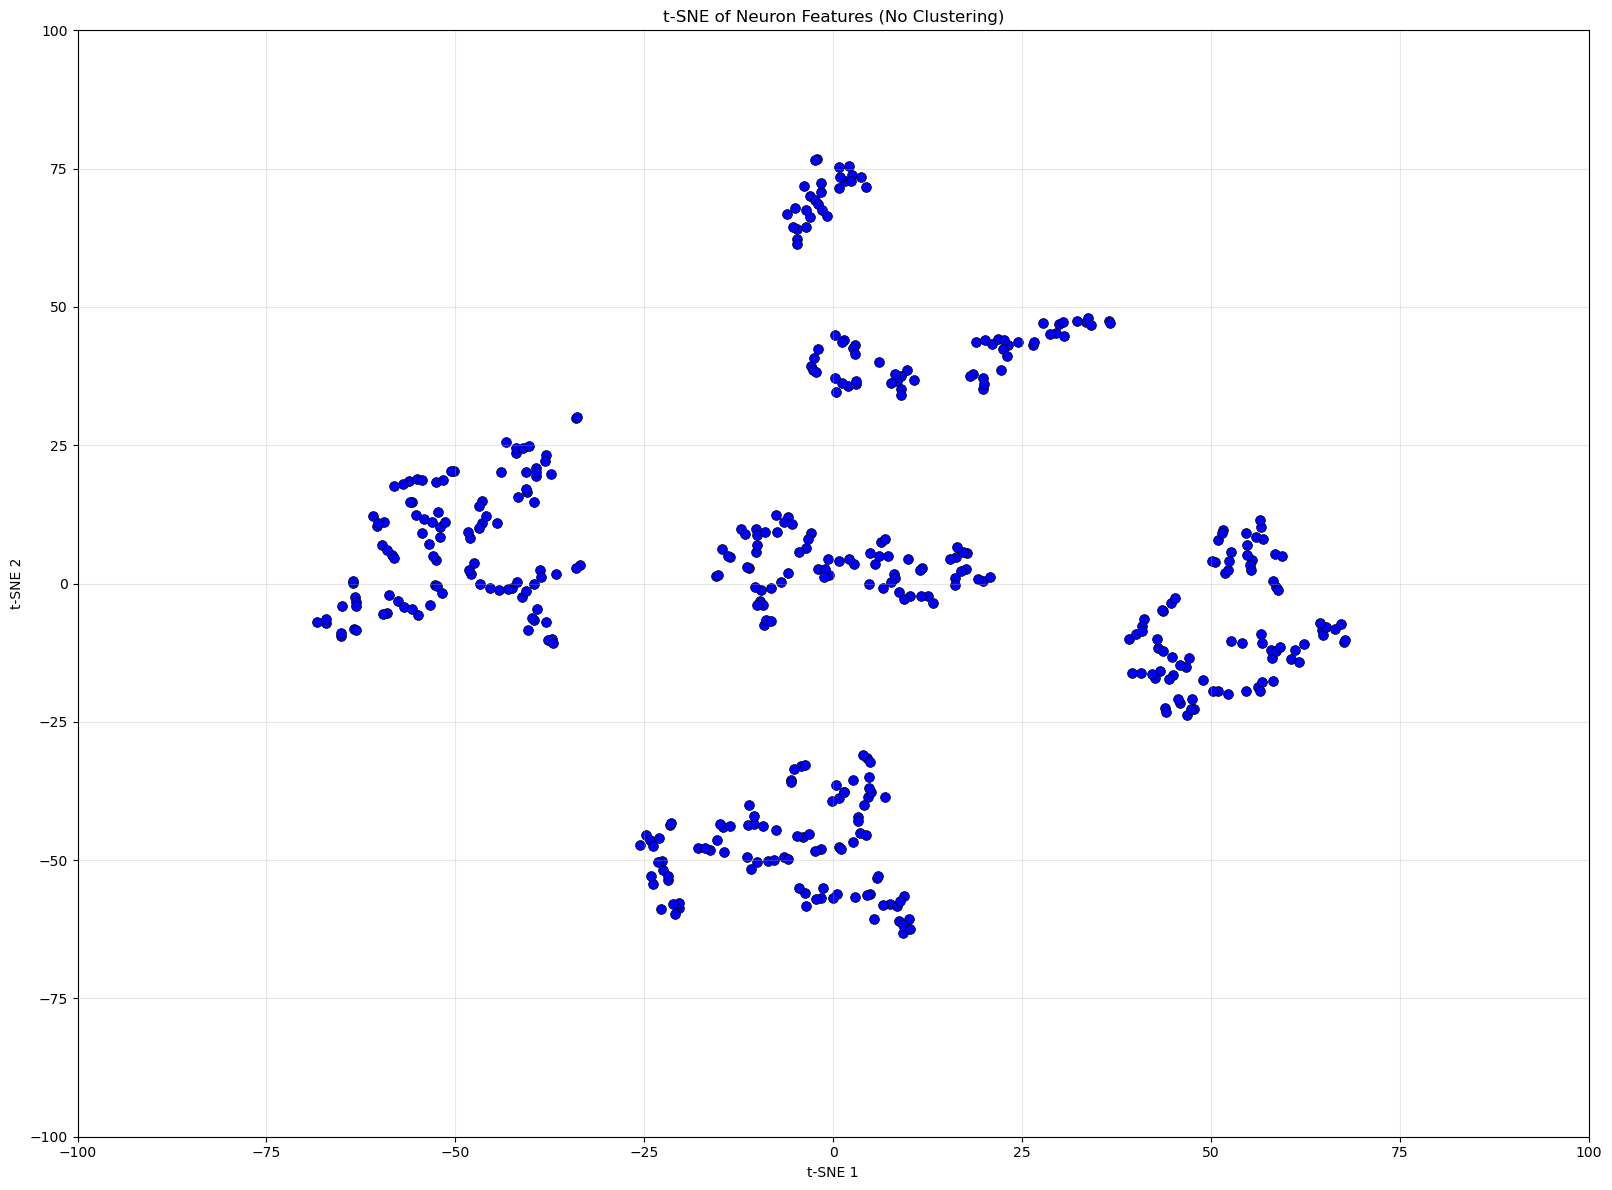

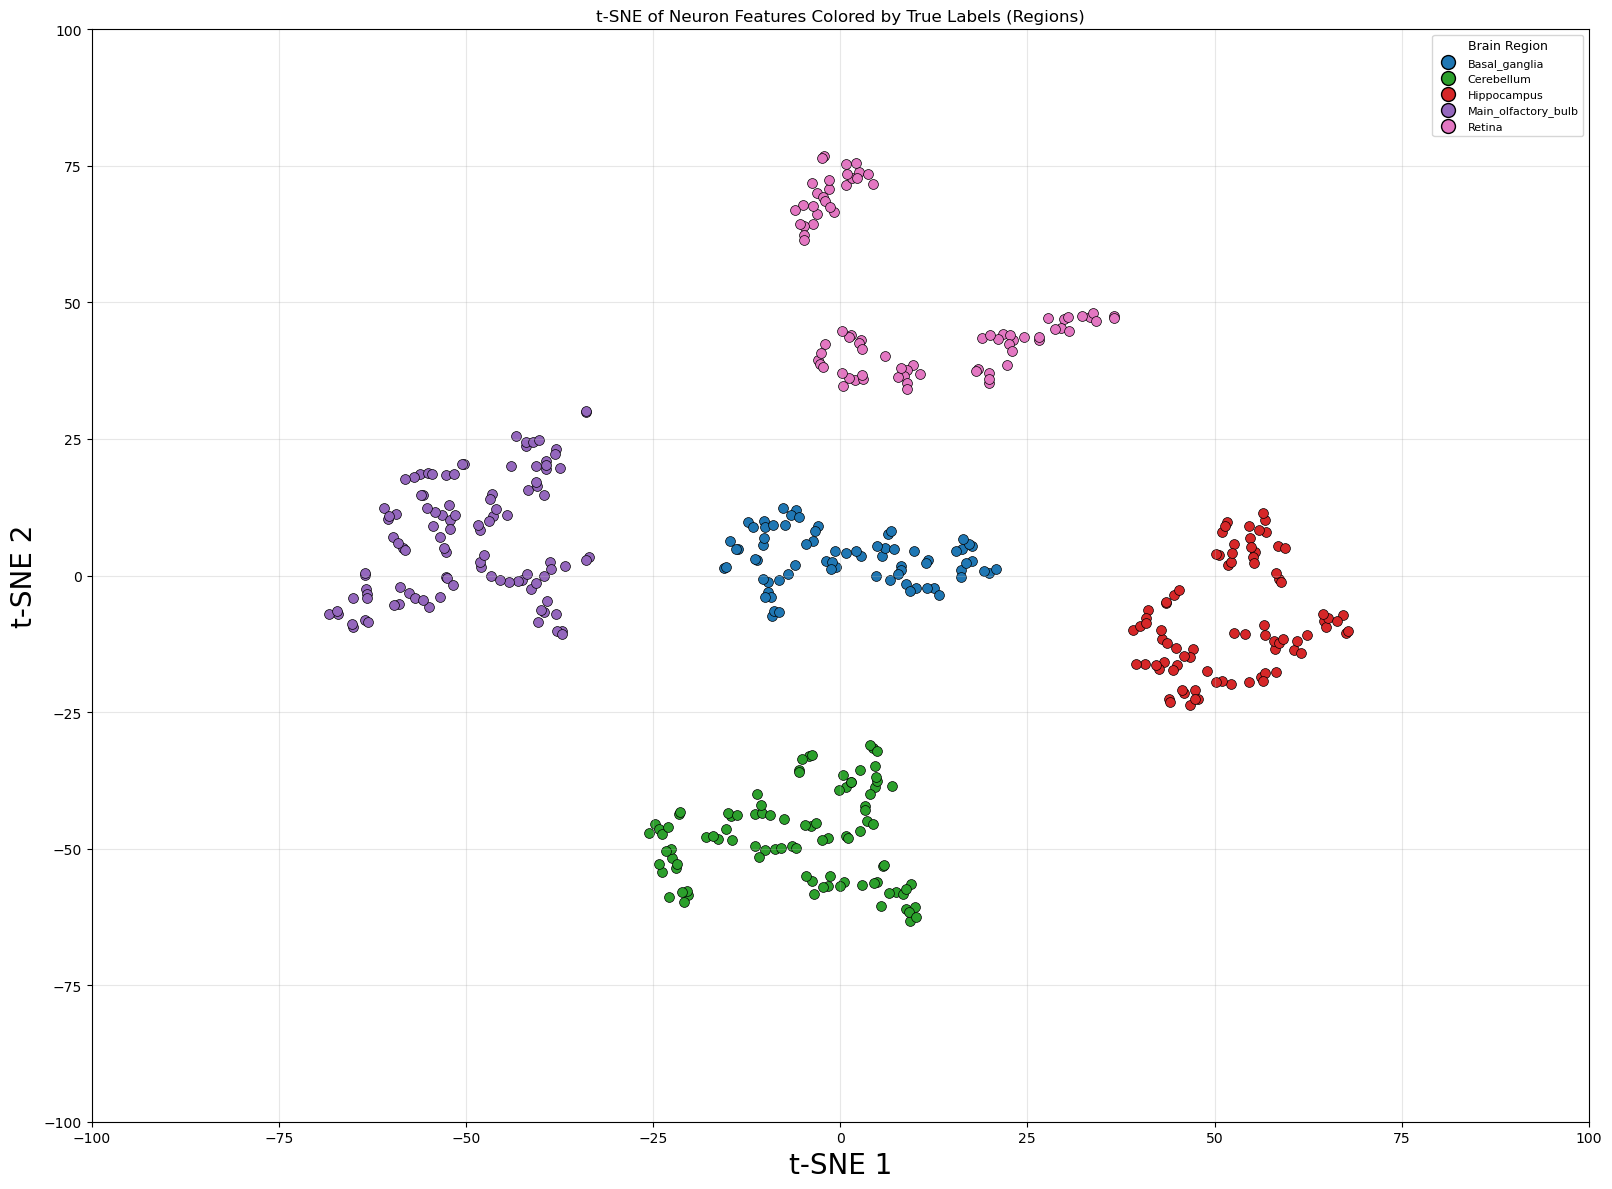

Adjusted Rand Score: 1.0000


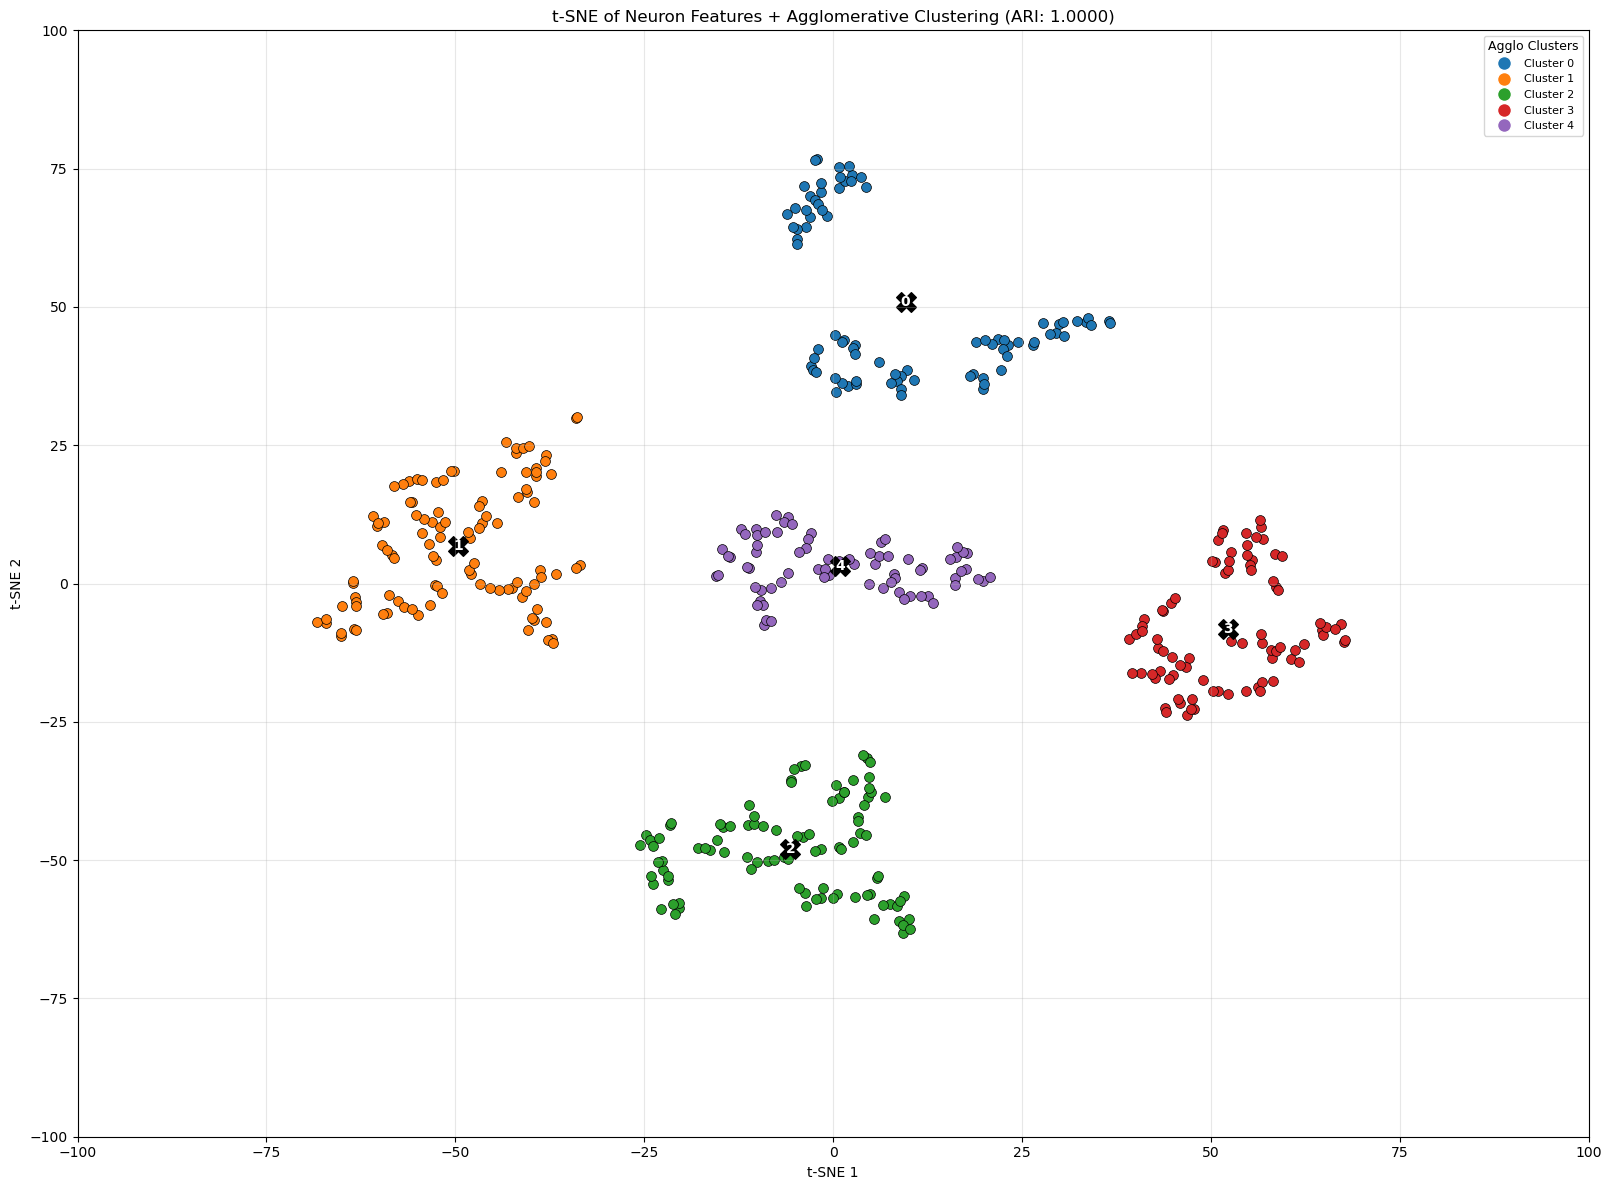

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import networkx as nx

csv_path = 'neuron_features.csv'
df = pd.read_csv(csv_path)

# Define the folder names in the order of labels (0 to 4)
folder_names = ['Basal_ganglia', 'Cerebellum', 'Hippocampus', 'Main_olfactory_bulb', 'Retina']

# Map numeric labels to actual region names
df['region'] = [folder_names[int(label)] for label in df['label']]

feature_columns = [
    'number_of_branches', 'avg_branch_length', 'edge_density',
    'mean_betweenness_centrality', 'diameter', 'average_path_length',
    'assortativity', 'spectral_entropy', 'circuity',
    'mass_quartile_1', 'mass_quartile_2', 'mass_quartile_3', 'mass_quartile_4',
    'directional_std_dev', 'weighted_entropy', 'orientation_order', 'fractal_dimension',
    'algebraic_connectivity','sum_avg_bending_energy'
]
X = df[feature_columns].values

# Normalize the features using standardization
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)


dist_matrix = euclidean_distances(X_norm)

# Save distance matrix
sample_ids = df['id'].tolist()
dist_df = pd.DataFrame(dist_matrix, index=sample_ids, columns=sample_ids)
dist_df.to_csv('1neuron_pairwise_euclidean_distances.csv')

# Perform t-SNE
tsne = TSNE(
    n_components=2,
    metric="precomputed",
    init='random',
    random_state=42,
    perplexity=6,
    learning_rate=100,
    n_iter=1000
)
tsne_coords = tsne.fit_transform(dist_matrix)

# Create DataFrame for plotting
df_plot = pd.DataFrame({
    "x": tsne_coords[:, 0],
    "y": tsne_coords[:, 1],
    "region": df['region'],
    "graph": sample_ids,
    "true_label": df['label']
})

# Map graph names to their folders (brain regions)
graph_to_region = dict(zip(sample_ids, df['region']))

# Plot t-SNE without clustering (all points in one color)
plt.figure(figsize=(16, 12))
plt.scatter(
    df_plot['x'],
    df_plot['y'],
    color='blue', # Single color for all points
    marker='o',
    s=50,
    edgecolor='k',
    linewidth=0.5
)
plt.title("t-SNE of Neuron Features (No Clustering)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.show()


plt.figure(figsize=(16, 12))

region_color_map = {
    'Basal_ganglia': '#1f77b4', # blue
    'Cerebellum': '#2ca02c', # green
    'Hippocampus': '#d62728', # red/brown
    'Main_olfactory_bulb': '#9467bd', # purple
    'Retina': '#e377c2' # pink
}
unique_regions = np.unique(df['region'])
for _, row in df_plot.iterrows():
    color = region_color_map.get(row['region'], 'gray') 
    plt.scatter(
        row['x'],
        row['y'],
        color=color,
        marker='o',
        s=50,
        edgecolor='k',
        linewidth=0.5
    )
# Legend for regions using the fixed colors
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=region,
           markerfacecolor=region_color_map.get(region, 'gray'), markeredgecolor='k', markersize=10)
    for region in sorted(unique_regions) # Sort for consistent order
]
plt.legend(handles=legend_elements, title="Brain Region", loc='upper right',
           fontsize=8, title_fontsize=9)
plt.title("t-SNE of Neuron Features Colored by True Labels (Regions)")
plt.xlabel("t-SNE 1", fontsize =20)
plt.ylabel("t-SNE 2", fontsize =20)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.savefig('neuron_pairwise.png', dpi =300)
plt.show()

# Perform Agglomerative Clustering on t-SNE coordinates
n_clusters = 5
agglo = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='ward'
)
cluster_labels = agglo.fit_predict(tsne_coords)

# Compute Adjusted Rand Score
ari = adjusted_rand_score(df['label'], cluster_labels)
print(f"Adjusted Rand Score: {ari:.4f}")

# Update df_plot with clusters
df_plot['cluster'] = cluster_labels

# Compute centroids
centroids = df_plot.groupby('cluster')[['x', 'y']].mean().reset_index()

# Plot t-SNE with clustering (5 clusters with distinct colors)
plt.figure(figsize=(16, 12))
cmap = plt.get_cmap("tab10")
for _, row in df_plot.iterrows():
    color = cmap(row['cluster'] % 10)
    plt.scatter(
        row['x'],
        row['y'],
        color=color,
        marker='o',
        s=50,
        edgecolor='k',
        linewidth=0.5
    )

# Legend for clusters
cluster_names = [f"Cluster {i}" for i in range(n_clusters)]
legend_elements_clusters = [
    Line2D([0], [0], marker='o', color='w', label=cluster_names[c],
           markerfacecolor=cmap(c % 10), markersize=10)
    for c in range(n_clusters)
]
plt.legend(handles=legend_elements_clusters,
           title="Agglo Clusters",
           loc='upper right',
           fontsize=8,
           title_fontsize=9)
plt.scatter(centroids['x'], centroids['y'],
            c='black', marker='X', s=200,
            label='Centroids')
for _, row in centroids.iterrows():
    plt.text(row['x'], row['y'], f"{int(row['cluster'])}",
             color='white', weight='bold',
             ha='center', va='center')
plt.title(f"t-SNE of Neuron Features + Agglomerative Clustering (ARI: {ari:.4f})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.show()

# # Function to find cluster center (closest graph to centroid)
# def find_cluster_center(df, cluster_id):
#     cluster_df = df[df['cluster'] == cluster_id]
#     if cluster_df.empty:
#         return None, None
#     centroid = np.array([cluster_df['x'].mean(), cluster_df['y'].mean()])
#     cluster_coords = cluster_df[['x', 'y']].to_numpy()
#     distances = cdist([centroid], cluster_coords, metric='euclidean')[0]
#     closest_idx = np.argmin(distances)
#     closest_graph = cluster_df.iloc[closest_idx]['graph']
#     return closest_graph, centroid

# # Function to plot neuron structure
# def plot_neuron_structure(graph_name, region):
#     core_path = './neuron_data/'
#     folder_path = os.path.join(core_path, region, 'CNG version')
#     if not os.path.exists(folder_path):
#         print(f"Folder not found: {folder_path}")
#         return
#     # Search for matching file
#     matching_files = [f for f in os.listdir(folder_path) if f.startswith(graph_name) and f.endswith('.swc')]
#     if not matching_files:
#         print(f"No matching SWC file found for {graph_name} in {folder_path}")
#         return
#     file_name = matching_files[0] # Take the first match
#     file_path = os.path.join(folder_path, file_name)
#     # Parse SWC file
#     nodes = {}
#     with open(file_path, 'r') as f:
#         for line in f:
#             if line.startswith('#'):
#                 continue
#             parts = line.strip().split()
#             if len(parts) != 7:
#                 continue
#             idx = int(parts[0])
#             typ = int(parts[1])
#             x = float(parts[2])
#             y = float(parts[3])
#             z = float(parts[4])
#             rad = float(parts[5])
#             parent = int(parts[6])
#             nodes[idx] = {'type': typ, 'pos': np.array([x, y, z]), 'radius': rad, 'parent': parent}
#     # Determine keep_types based on folder
#     if region == 'Cerebellum':
#         keep_types = {3, 4} # dendrites only
#     elif region == 'Retina':
#         keep_types = {1, 3, 4} # soma and dendrites, remove axon
#     else:
#         keep_types = {1, 3, 4} # soma and dendrites
#     # Filter nodes
#     kept_nodes = {k: v for k, v in nodes.items() if v['type'] in keep_types}
#     if len(kept_nodes) == 0:
#         print(f"Skipping plot for {graph_name}: No kept nodes")
#         return
#     # Build graph
#     graph = nx.Graph()
#     for node in kept_nodes:
#         graph.add_node(node)
#         p = kept_nodes[node]['parent']
#         if p != -1 and p in kept_nodes:
#             graph.add_edge(p, node)
#     # Plot the structure (2D projection: x vs y)
#     fig, ax = plt.subplots(figsize=(8, 8))
#     for u, v in graph.edges():
#         pos_u = kept_nodes[u]['pos'][:2] # x, y
#         pos_v = kept_nodes[v]['pos'][:2]
#         ax.plot([pos_u[0], pos_v[0]], [pos_u[1], pos_v[1]], 'k-', linewidth=1.5)
#     plt.title(f"Neuron Structure: {graph_name} ({region}, {cluster_names[cluster_id]})")
#     plt.xlabel("X")
#     plt.ylabel("Y")
#     plt.axis('equal')
#     plt.grid(True, linestyle='--', alpha=0.3)
#     plt.tight_layout()
#     plt.show()

# # Generate plots for the center of each cluster
# for cluster_id in range(n_clusters):
#     closest_graph, centroid = find_cluster_center(df_plot, cluster_id)
#     if closest_graph is None:
#         print(f"Cluster {cluster_id} is empty")
#         continue
#     region = graph_to_region[closest_graph]
#     print(f"Cluster {cluster_id} center: {closest_graph} ({region})")
#     plot_neuron_structure(closest_graph, region)